<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/gradient_descent_part1_New_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Approach
# **Gradient Descent for Linear Regression. Part 1/2**
#### **Understanding the Algorithm and Basic Implementation**  


 <a href="https://github.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white" alt="GitHub" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.kaggle.com/magnitopic" target="_blank"><img src="https://img.shields.io/badge/Kaggle-20BEFF?style=flat&logo=kaggle&logoColor=white" alt="Kaggle" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a><a href="https://www.linkedin.com/in/magnitopic" target="_blank"><img src="https://img.shields.io/badge/LinkedIn-0A66C2?style=flat&logo=linkedin&logoColor=white" alt="LinkedIn" style="display: inline-block; vertical-align: middle; margin-right: 10px;"/></a>

> **Esta es la Parte 1 de 2 en nuestra serie sobre Gradient Descent.**
> Aquí aprenderás la intuición, las matemáticas esenciales y la implementación básica del algoritmo. En la Parte 2 abordaremos los hiperparámetros, el escalado de características y las implementaciones profesionales.

Si quieres repasar los fundamentos de la regresión lineal y el método de mínimos cuadrados, te recomiendo leer primero mi artículo [Linear Regression from Scratch in Python](https://www.kaggle.com/code/magnitopic/linear-regression-from-scratch-in-python-part-1-2), donde se abordan estos conceptos desde cero.

### El algoritmo estrella del Machine Learning

El Descenso del Gradiente es el motor de optimización detrás de prácticamente todo el Machine Learning moderno. En este artículo, aprenderás cómo funciona este algoritmo aplicándolo a la Regresión Lineal, combinando teoría accesible con código práctico para que entiendas **por qué funciona** y **cómo implementarlo** paso a paso.

Al final de este artículo, habrás construido tu propio algoritmo de Gradient Descent desde cero y entenderás la base sobre la que se construyen las redes neuronales.

---

## **1. Introducción: ¿Qué problema queremos resolver?**

En el corazón del Machine Learning se encuentra una tarea fundamental: la **predicción**. Queremos usar datos que ya tenemos para hacer estimaciones inteligentes sobre datos que aún no hemos visto.

Tomemos un ejemplo clásico y práctico: **predecir el precio de una vivienda basándonos en su tamaño**.

### El problema de predicción

Imagina que dispones de un conjunto de datos de casas. Para cada una conoces su **tamaño en metros cuadrados** (nuestra variable de entrada $x$) y el **precio de venta** (nuestra variable objetivo $y$). Si representamos estos datos en un gráfico de dispersión, veremos una nube de puntos con una tendencia clara: a mayor área, mayor precio (aunque con cierta dispersión).

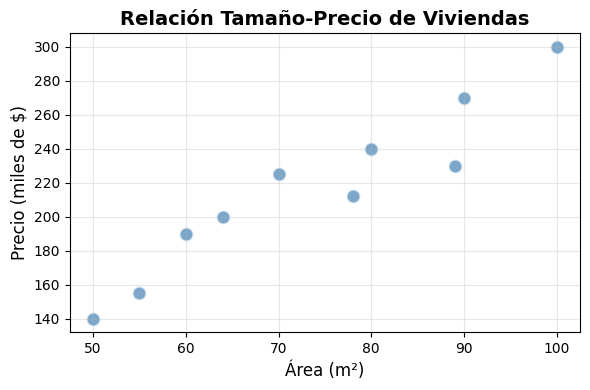

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de ejemplo: tamaño de vivienda vs precio
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
precio = np.array([140000, 155000, 190000, 200000, 225000,
                  212000, 240000, 230000, 270000, 300000])

plt.figure(figsize=(6, 4))
plt.scatter(area, precio/1000, alpha=0.7, s=100, color='steelblue', edgecolors='white', linewidth=1.5)
plt.xlabel('Área (m²)', fontsize=12)
plt.ylabel('Precio (miles de $)', fontsize=12)
plt.title('Relación Tamaño-Precio de Viviendas', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Nuestro objetivo es encontrar **una línea recta** que capture lo mejor posible esta tendencia. Esta línea será nuestro modelo de **Regresión Lineal**.

¿Por qué esto es interesante? Porque una vez entrenado el modelo, si nos dan el área de una nueva casa ($x$), podremos usar la línea para **estimar** su precio probable ($\hat{y}$).

### La ecuación del modelo

La ecuación de una recta es bien conocida:

$$\hat{y} = w_0 + w_1 x$$

Donde:
- $x$: área de la vivienda es nuestra variable de entrada (el *feature*).
- $\hat{y}$: precio estimado es la predicción de nuestro modelo. La distinguimos de la $y$ real (el precio de venta verdadero).
- $w_0$: **intercepto** o sesgo (bias). Valor de $\hat{y}$ cuando $x = 0$.
- $w_1$: **pendiente** o peso (weight). Cuánto aumenta el precio por cada metro cuadrado adicional.

**Objetivo:** Encontrar los parámetros $ w_0 $ y $ w_1 $ que nos den la recta que mejor se ajuste a la nube de puntos.

Existen dos enfoques principales:

1. **Solución cerrada (Ecuación Normal)**  
   Una fórmula analítica directa:  
   $$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$  
   Es exacta y rápida para datasets pequeños, pero se vuelve muy costosa (y a veces imposible) con millones de datos o miles de variables.

2. **Descenso del Gradiente (Gradient Descent)**  
   Un algoritmo iterativo que "camina" hacia los valores óptimos ajustando progresivamente los parámetros.  
   **Ventajas clave:**
   - Escala a datasets enormes y a miles de características
   - Funciona con datos que no caben en memoria (procesamiento por lotes)
   - Es la base de prácticamente todo el Deep Learning
   - Permite actualización continua del modelo (online learning)
   - Funciona para problemas no lineales y redes neuronales

En problemas reales (cientos de miles o millones de observaciones), la solución cerrada simplemente no es viable. Por eso necesitamos entender y dominar el **Descenso del Gradiente**.

### ¿Qué aprenderás en esta Parte 1?

- La intuición detrás del algoritmo.
- Cómo medir el error de una recta: la **función de costes**.
- Las matemáticas esenciales: qué es el gradiente y por qué “descender” nos lleva al mínimo.
- Implementar Gradient Descent desde cero con NumPy.
- Visualizar el proceso de optimización y entender qué ocurre internamente en cada paso.

En la **Parte 2** profundizaremos en:
- hiperparámetros críticos (learning rate)
- escalado de características
- variantes del algoritmo (Batch, Mini-Batch, SGD)
- comparación con implementaciones profesionales como scikit-learn.

Pero antes de implementar nada, necesitamos responder una pregunta fundamental: ¿cómo medimos qué tan "buena" o "mala" es una recta? Para eso, introduciremos la Función de Costes.

## **2. Midiendo el Error: La Función de Costes**

Para encontrar la "mejor" recta, necesitamos una forma objetiva de medir qué tan bien se ajusta una línea a los datos.

### El resíduo: el error en un punto

Para cada vivienda $i$, conocemos su área real $x_i$ y su precio real $y_i$. Nuestra recta predice un precio $\hat{y}_i = w_0 + w_1 x_i$.

La diferencia vertical entre el punto real y la predicción se llama **residuo**:

$$e_i = y_i - \hat{y}_i$$

- Si $e_i > 0$, el punto está por encima de la recta (subestimamos el precio).
- Si $e_i < 0$, el punto está por debajo (sobreestimamos).

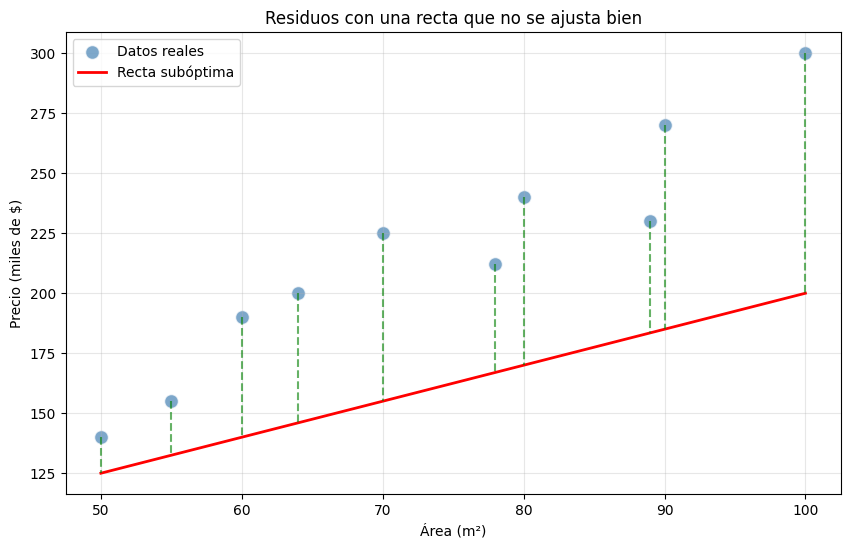

In [6]:
# Visualización rápida de residuos con una recta arbitraria
w0_bad, w1_bad = 50000, 1500
y_pred_bad = w0_bad + w1_bad * area

plt.figure(figsize=(10, 6))
plt.scatter(area, precio/1000, s=100, alpha=0.7, color='steelblue', edgecolors='white', label='Datos reales')
plt.plot(area, y_pred_bad/1000, 'r-', linewidth=2, label='Recta subóptima')
for i in range(len(area)):
    plt.plot([area[i], area[i]], [precio[i]/1000, y_pred_bad[i]/1000], 'g--', alpha=0.6)
plt.xlabel('Área (m²)')
plt.ylabel('Precio (miles de $)')
plt.title('Residuos con una recta que no se ajusta bien')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### El error total: ¿por qué no basta con sumar los residuos?

Un impulso inicial sería sumar todos los residuos. Pero esto es problemático: los errores positivos y negativos se cancelan, pudiendo dar la falsa impresión de que no hay error cuando en realidad la recta está muy alejada de muchos puntos.

### Solución: Error Cuadrático Medio (MSE)

Para evitar cancelaciones y penalizar más los errores grandes:

1. Elevamos cada residuo al cuadrado: $e_i^2 = (y_i - \hat{y}_i)^2$
    - siempre positivo
    - penaliza los errores grandes mucho más
2. Calculamos la media de todos los errores al cuadrado que es la **Mean Squared Error (MSE)**.

Esta métrica es nuestra **Función de Costes** $J$:

$$J(w_0, w_1) = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 = \frac{1}{m} \sum_{i=1}^{m} (y_i - (w_0 + w_1 x_i))^2$$

donde $m$ es el número de datos.

> **Nota:** En algunos textos verás $\frac{1}{2m}$ en lugar de $\frac{1}{m}$. El factor $\frac{1}{2}$ solo simplifica las derivadas posteriores, pero no cambia la posición del mínimo.

In [8]:
def mse(w0, w1, x, y):
    """Calcula el Error Cuadrático Medio"""
    m = len(y)
    y_pred = w0 + w1 * x
    return (1/m) * np.sum((y - y_pred)**2)

# Calculamos el MSE para nuestra línea subóptima
mse_bad = mse(w0_bad, w1_bad, area, precio)
rmse_bad = np.sqrt(mse_bad)

print(f"MSE con la recta subóptima: {mse_bad:,.0f}")
print(f"RMSE (raíz del MSE): ${rmse_bad:,.0f}")
print(f"En promedio, las predicciones se desvían unos ${rmse_bad:,.0f} del precio real")

MSE con la recta subóptima: 3,735,950,000
RMSE (raíz del MSE): $61,122
En promedio, las predicciones se desvían unos $61,122 del precio real


### El nuevo objetivo

Los datos $x$ e $y$ son fijos. Por tanto, $J$ no depende de $x$, depende solo de los parámetros $w_0$ y $w_1$.

- Diferentes valores de $w_0$ y $w_1$ (diferentes líneas) nos darán un coste $J$ diferente.
- Una línea mala tendrá un coste $J$ muy alto.
- Una línea buena tendrá un coste $J$ muy bajo.
- **La línea perfecta** minimizará $J$.

Si representamos $J(w_0, w_1)$ en un gráfico 3D, obtenemos una superficie con forma de cuenco (convexa). Nuestro problema se reduce a encontrar el punto más bajo de ese cuenco. Es un problema de minimización.

El algoritmo que nos llevará hasta el fondo del valle es el **Descenso del Gradiente**, que veremos en la siguiente sección.

## **3. La Intuición del Descenso del Gradiente**